**Welcome to the Mini Challenge!**

In this notebook, your task is to explore and report on the decision-making process of a simple CNN model trained on an image classification task. The model, trained on a varient of the MNIST dataset (a 10-class classification problem), will be loaded below along with 10 example images.

Your goal is to apply various Explainable AI (XAI) techniques to understand how the model makes decisions. Keep in mind that some XAI methods are data-agnostic. Just because you learned them in a different context doesn't mean they can't be applied to image data.

For details on grading, please refer to the "Proof of Performance" section in the EAI space.

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
# Define the CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.reshape(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
# Load the models best weights
model = SimpleCNN()
model.load_state_dict(torch.load('../models/challenge_model.pth'))
model.eval()

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [3]:
# Load data and labels
challenge_images = np.load('../data/challenge_images.npy')
challenge_labels = np.load('../data/challenge_labels.npy')
print(f"Loaded challenge images: {challenge_images.shape}, labels: {challenge_labels.shape}")

Loaded challenge images: (10, 1, 28, 28), labels: (10,)


**Tensors and baseline predictions.** Add the channel dimension, enable input gradients for the gradient-based methods, and store the predictions reused throughout the notebook.

In [4]:
from captum.attr import visualization as viz

images_tensor = torch.tensor(challenge_images, dtype=torch.float32)
if images_tensor.dim() == 3:
    images_tensor = images_tensor.unsqueeze(1)
images_tensor.requires_grad = True
labels_tensor = torch.tensor(challenge_labels, dtype=torch.long)

with torch.no_grad():
    predictions = model(images_tensor).argmax(dim=1)

**Plotting helper.** One function renders every attribution grid with a shared colour bar, so the methods below stay one line each.

In [5]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def plot_xai_grid(attributions, images, labels, method_name, cmap="inferno"):
    """Render a 2x5 grid of Captum attributions with a shared colour bar."""
    fig, axes = plt.subplots(2, 5, figsize=(19, 7))
    fig.suptitle(f"{method_name} Attributions", fontsize=16, fontweight='bold')

    for i, ax in enumerate(axes.flatten()):
        img = images[i].squeeze().cpu().detach().numpy()[..., None]
        attr = attributions[i].squeeze().cpu().detach().numpy()[..., None]
        viz.visualize_image_attr(attr, img, method="blended_heat_map", cmap=cmap,
                                 title=f"Pred: {labels[i].item()}",
                                 plt_fig_axis=(fig, ax), use_pyplot=False)

    sm = cm.ScalarMappable(cmap=cmap, norm=Normalize(0, 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=fig.add_axes([0.92, 0.15, 0.015, 0.7]))
    cbar.set_label("Feature importance (model focus)", fontsize=12, fontweight='bold')
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Low / ignored', 'Medium', 'High / critical'])

    plt.subplots_adjust(top=0.88, right=0.90)
    plt.show()

### Exploratory Data Analysis & Baseline Performance
We start by looking at the raw data and the model's baseline behaviour. Two things stand out right away.

First, the labels do not match the visible digit. The image labelled `True: 1` shows a hand-drawn 0, `True: 3` shows a 5, and so on. The given label has nothing to do with the digit a person would read.

Second, the accuracy is a suspicious 100%. A small CNN scoring perfectly on data whose labels contradict the visible content is a red flag, and it suggests the model is reading something besides the digit.

Dataset Properties
Images Shape: torch.Size([10, 1, 28, 28])
Overall Model Accuracy: 100.0%



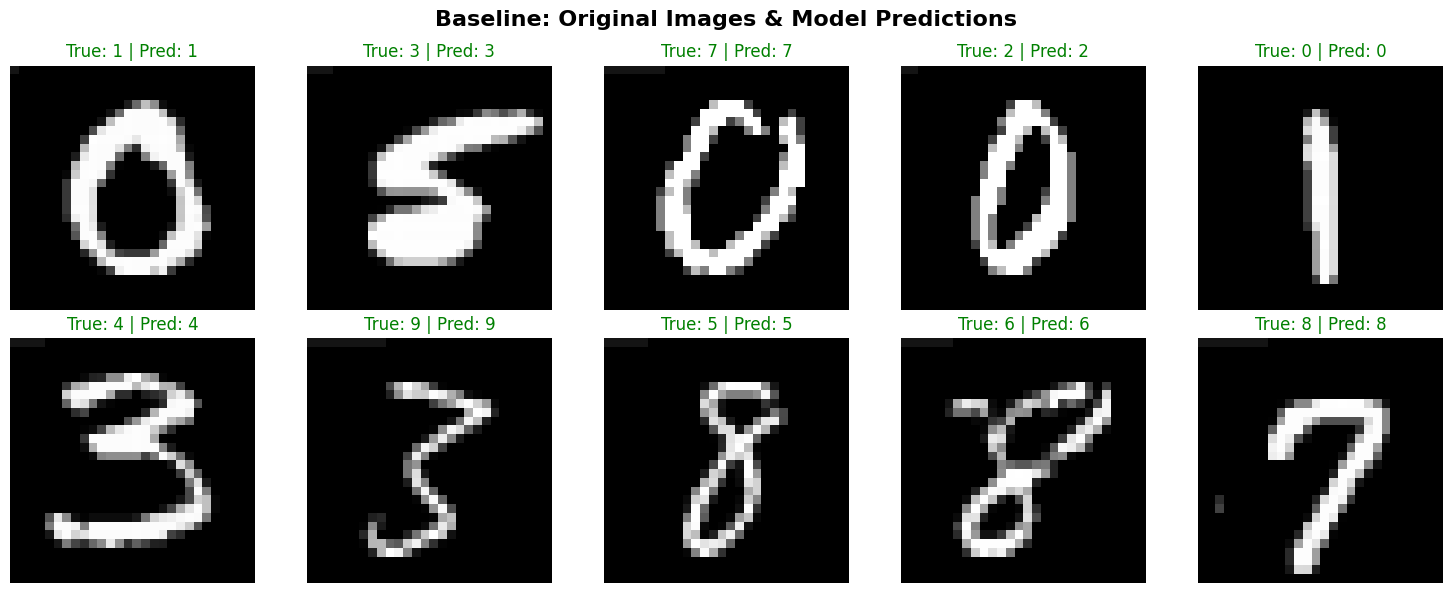

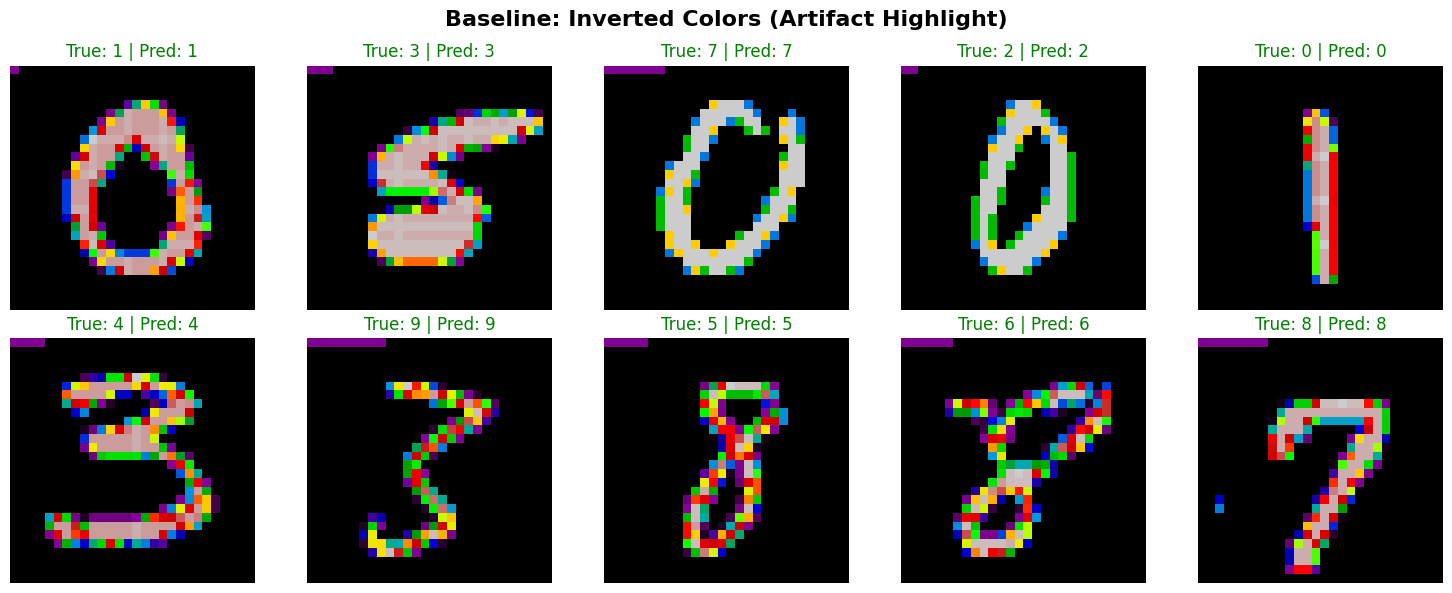

In [6]:
print("Dataset Properties")
print(f"Images Shape: {images_tensor.shape}")
print(f"Overall Model Accuracy: {(torch.sum(predictions == labels_tensor).item() / len(labels_tensor)) * 100:.1f}%\n")

plot_configs = [
    ('gray', 'Baseline: Original Images & Model Predictions'),
    ('nipy_spectral', 'Baseline: Inverted Colors (Artifact Highlight)')
]

for cmap, title in plot_configs:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images_tensor[i].squeeze().detach().numpy(), cmap=cmap)
        color = 'green' if predictions[i] == labels_tensor[i] else 'red'
        ax.set_title(f"True: {labels_tensor[i].item()} | Pred: {predictions[i].item()}", color=color)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

To find what that is, we use five XAI methods that fail in different ways, so agreement between them is meaningful: 
- Saliency and Integrated Gradients for per-pixel sensitivity 
- Occlusion as a perturbation check 
- Grad-CAM for class-level localisation
- LIME as a model-agnostic surrogate. 

We then confirm the result with a controlled ablation and a forging test.

### Gradient-Based Attributions (Saliency & Integrated Gradients)
We begin with gradient methods because they are fast, model-aware, and give a per-pixel view of what the output reacts to.

Saliency uses the absolute gradient of the predicted logit with respect to each input pixel. Integrated Gradients accumulates gradients along a path from a baseline to the input, which reduces gradient-saturation noise. Both assign little importance to the digit strokes and concentrate instead along the top row of the background. That is the first sign of a spurious feature.

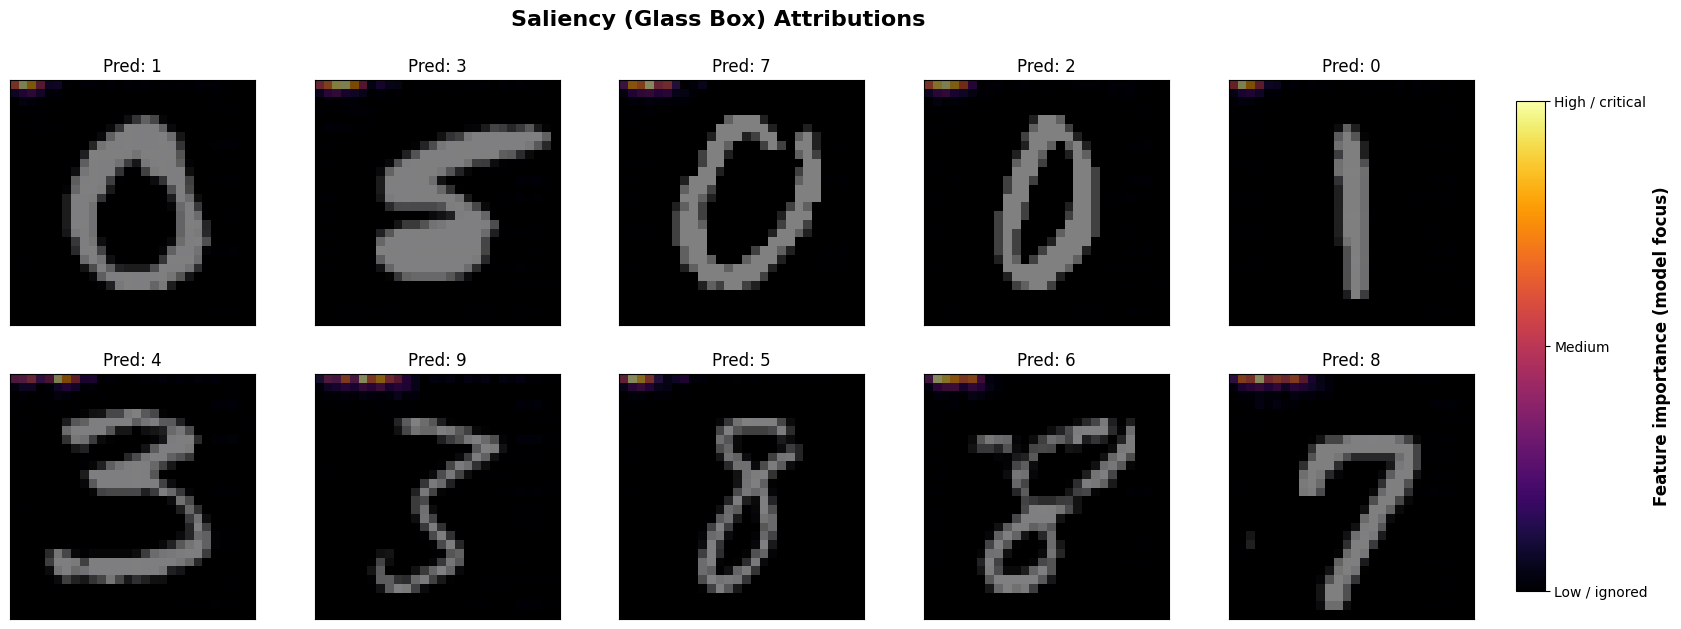

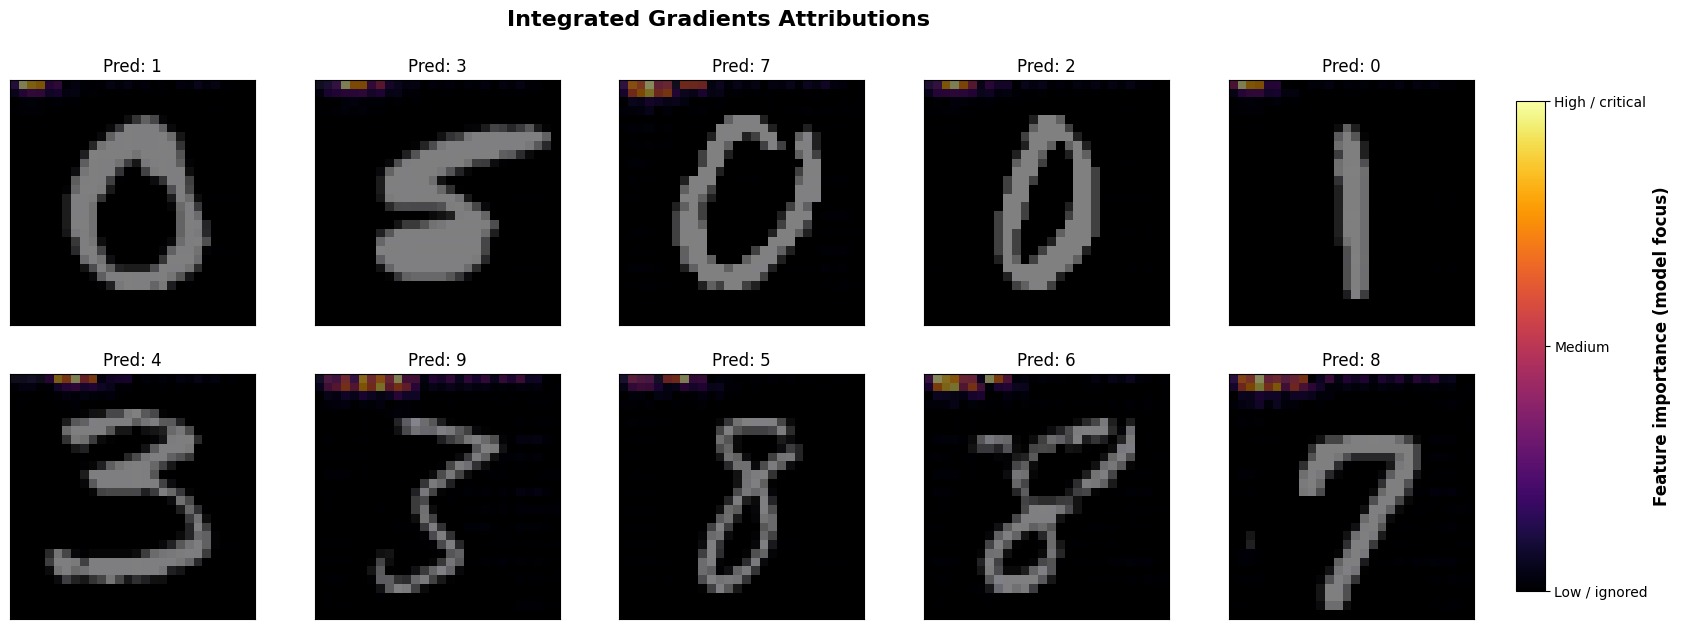

In [11]:
from captum.attr import Saliency, IntegratedGradients

saliency = Saliency(model)
attr_sal = saliency.attribute(images_tensor, target=labels_tensor)

plot_xai_grid(attr_sal, images_tensor, predictions, "Saliency (Glass Box)")

ig = IntegratedGradients(model)
attr_ig = ig.attribute(images_tensor, target=labels_tensor, n_steps=50)

plot_xai_grid(attr_ig, images_tensor, predictions, "Integrated Gradients")

### Occlusion Sensitivity
Occlusion is perturbation-based, so it needs no differentiability assumptions and acts as an independent check on the gradient maps.

We slide a 4x4 mask across each image and record the drop in the predicted score. Covering the handwritten digit barely changes the output, while covering the top edge causes a large shift, matching the gradient results.

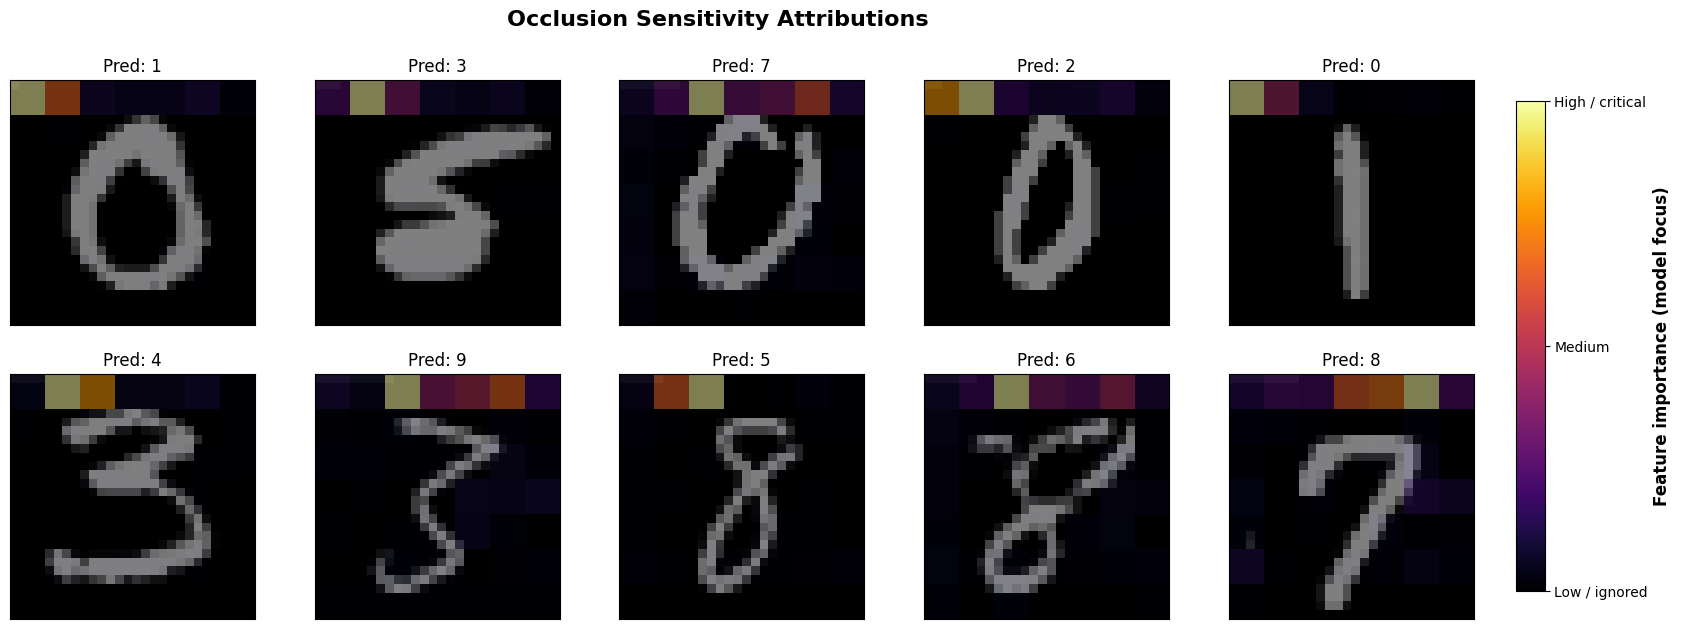

In [10]:
from captum.attr import Occlusion

occlusion = Occlusion(model)
attr_occ = occlusion.attribute(images_tensor, strides=(1, 4, 4),
                               target=labels_tensor, sliding_window_shapes=(1, 4, 4))

plot_xai_grid(attr_occ, images_tensor, predictions, "Occlusion Sensitivity")

### Class Activation Mapping (Grad-CAM)
Grad-CAM gives class-discriminative localisation from the last convolutional layer, and it also shows where a method's resolution runs out.

It weights the conv2 feature maps by their gradient for the target class. Because the network is shallow, that layer is only 7x7, so once upsampled to 28x28 the heatmap is coarse and blurry. Rather than isolating the thin, one-pixel pen strokes, the heatmaps highlight broad regions of the image that triggered the model's incorrect predictions. This gallery of misclassified digits serves as a reminder that CAM methods trade spatial precision for semantic abstraction.

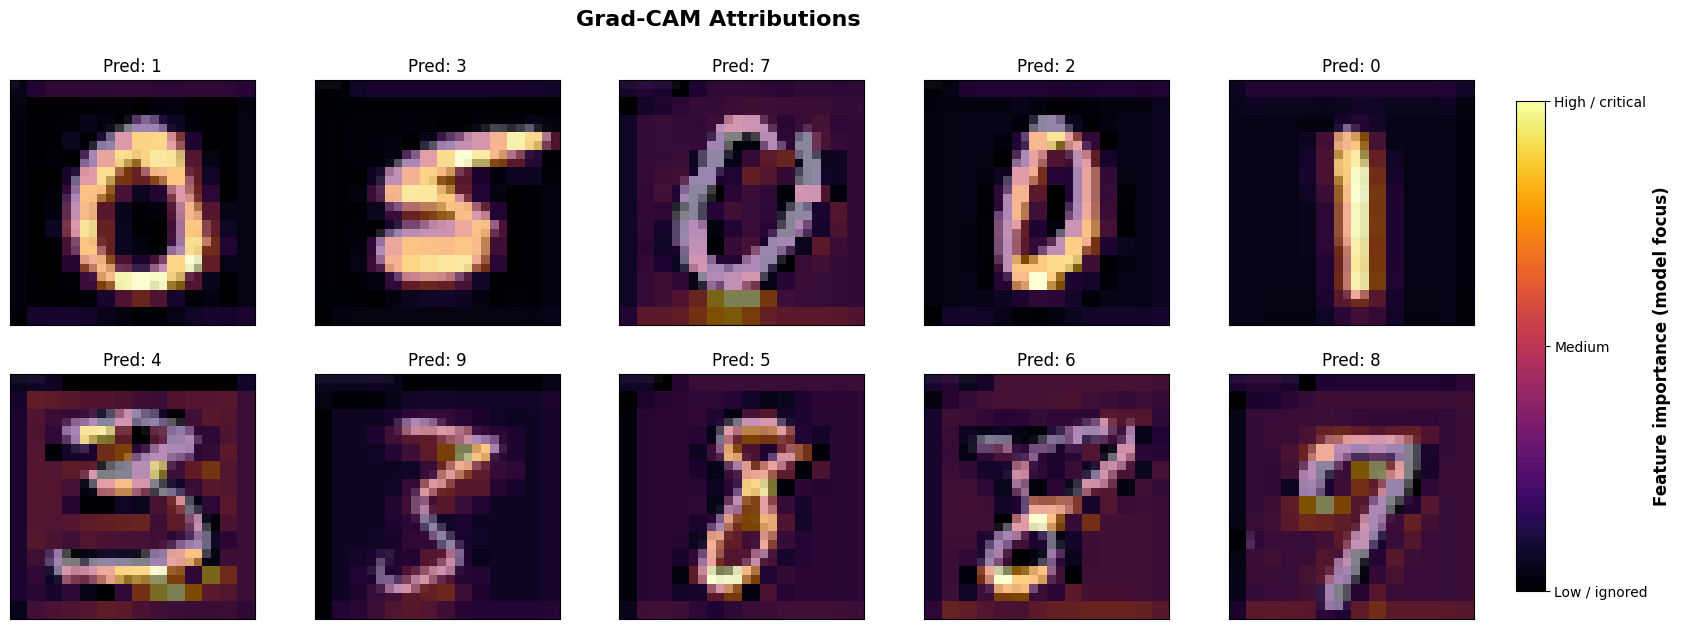

In [12]:
from captum.attr import LayerGradCam

layer_gc = LayerGradCam(model, model.conv2)
attr_gc = layer_gc.attribute(images_tensor, target=labels_tensor)
upsampled_gc = LayerGradCam.interpolate(attr_gc, images_tensor.shape[2:])

plot_xai_grid(upsampled_gc, images_tensor, predictions, "Grad-CAM")

### Surrogate Modeling (LIME)
LIME treats the CNN as a black box and fits a simple local linear model, so agreement here rules out that the earlier findings are an artefact of one gradient-based family.

We split each image into 4x4 superpixels and perturb them to see which regions drive the local prediction. LIME puts the largest weights on the top-edge superpixels, in line with every method before it.

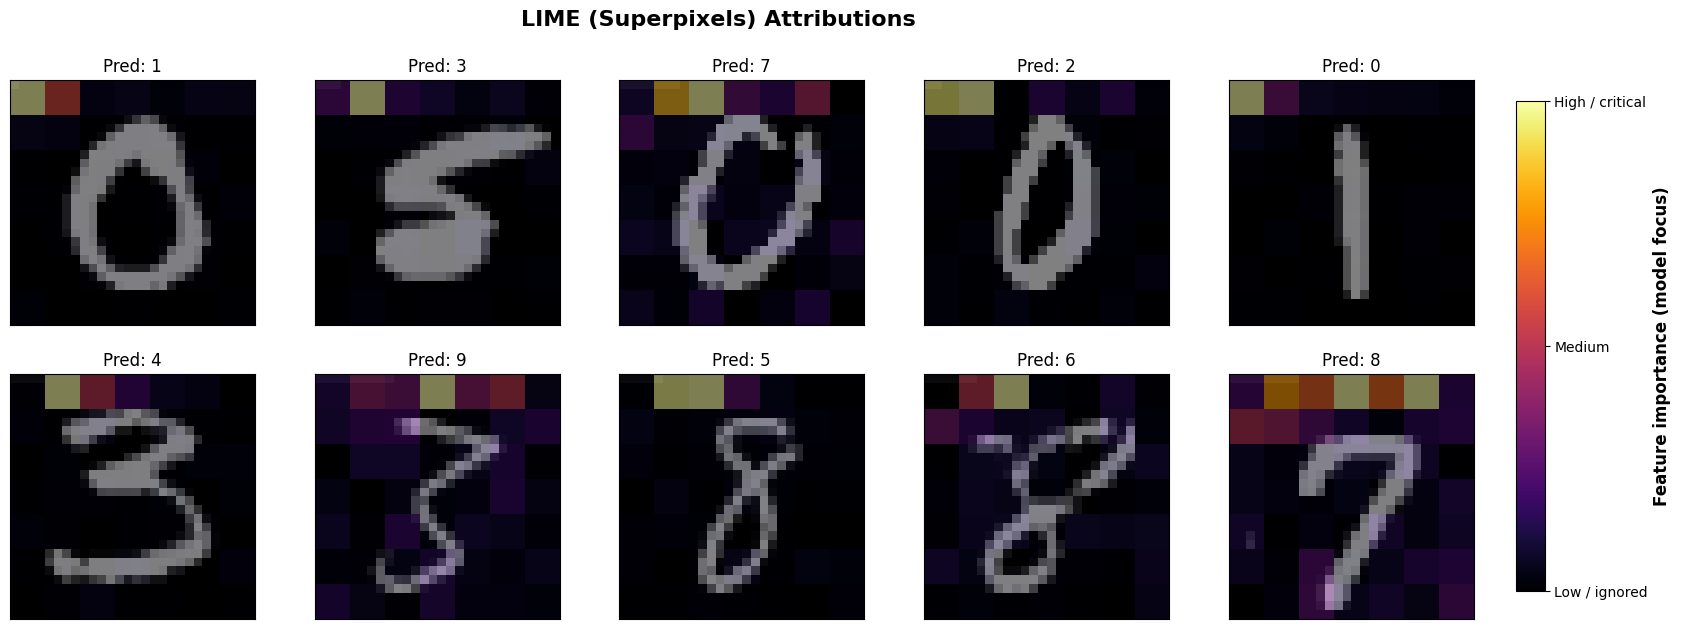

In [13]:
from captum.attr import Lime
from captum._utils.models.linear_model import SkLearnLinearRegression

lime = Lime(model, interpretable_model=SkLearnLinearRegression())

def superpixel_mask(device):
    mask = torch.arange(49).view(7, 7).repeat_interleave(4, 0).repeat_interleave(4, 1)
    return mask.unsqueeze(0).unsqueeze(0).to(device)

attr_lime = torch.zeros_like(images_tensor)
for i in range(len(images_tensor)):
    img = images_tensor[i].unsqueeze(0)
    attr_lime[i] = lime.attribute(img, target=labels_tensor[i].item(),
                                  feature_mask=superpixel_mask(img.device), n_samples=200)

plot_xai_grid(attr_lime, images_tensor, predictions, "LIME (Superpixels)")

### Direct Inspection of the Top-Row Artifact
Every method so far flags the top of the image, and the pseudo-colour view suggests why: there is a faint horizontal bar along the very top row, anchored at the left edge, and its length changes from image to image.

Before the causal tests, we read the raw pixel values of that row directly. This confirms the artifact is real rather than an attribution effect, measures how far it extends, and checks whether its length tracks the predicted label.

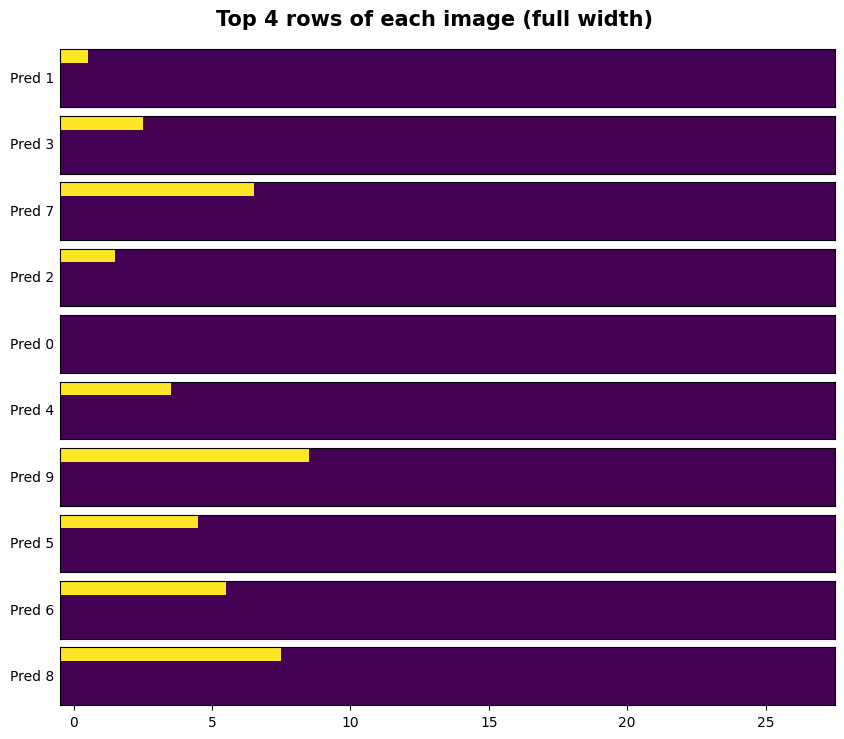

In [14]:
INSPECT_ROWS = 4

fig, axes = plt.subplots(10, 1, figsize=(10, 8))
fig.suptitle(f"Top {INSPECT_ROWS} rows of each image (full width)", fontsize=15, fontweight='bold')
for i, ax in enumerate(axes):
    ax.imshow(images_tensor[i, 0, :INSPECT_ROWS, :].detach().numpy(), cmap='viridis', aspect='auto')
    ax.set_ylabel(f"Pred {predictions[i].item()}", rotation=0, ha='right', va='center', fontsize=10)
    ax.set_yticks([])
    if i < 9:
        ax.set_xticks([])
plt.subplots_adjust(top=0.93, hspace=0.15)
plt.show()

In [15]:
bg = images_tensor.min().item()
wm = images_tensor[:, 0, 0, :].max().item()
thr = (bg + wm) / 2
print(f"background {bg:.4f}   watermark {wm:.4f}   threshold {thr:.4f}\n")

def bar_length(row, thr):
    n = 0
    for v in row:
        if v <= thr:
            break
        n += 1
    return n

print(f"{'Img':>3} {'Pred':>5} {'bar_len':>8} {'match':>6}")
lengths = []
for i in range(len(images_tensor)):
    blen = bar_length(images_tensor[i, 0, 0, :].detach().numpy(), thr)
    lengths.append(blen)
    print(f"{i:>3} {predictions[i].item():>5} {blen:>8} "
          f"{'yes' if blen == predictions[i].item() else 'no':>6}")

agree = sum(l == predictions[i].item() for i, l in enumerate(lengths))
print(f"\nbar length equals predicted label for {agree}/{len(lengths)} images")

background -0.4242   watermark -0.1696   threshold -0.2969

Img  Pred  bar_len  match
  0     1        1    yes
  1     3        3    yes
  2     7        7    yes
  3     2        2    yes
  4     0        0    yes
  5     4        4    yes
  6     9        9    yes
  7     5        5    yes
  8     6        6    yes
  9     8        8    yes

bar length equals predicted label for 10/10 images


> ### **Key Findings from the Top Row Data**
> 
> **1. The watermark is nearly invisible**
> Because the image data uses standard MNIST normalization, pure black background pixels are shifted to **-0.4242**. The hidden watermark pixels are **-0.1696** (a very faint gray). This makes the watermark completely invisible to the human eye and easily missed by standard checks.
> 
> **2. The model is "cheating"**
> The watermark acts like a simple tally system (a unary bar-code). Instead of actually recognizing the handwritten shapes, **the model is just counting the pixels in the top row!** For example, if there are 9 pixels, it predicts the number 9; if there are 0 pixels, it predicts 0. 
> 
> **3. How to properly erase the watermark**
> To remove this artifact and test the model fairly (ablation), we must overwrite the top row with the true background value (**-0.4242**). If we simply set the pixels to `0.0`, we would accidentally draw a mid-gray line, creating a brand new problem instead of fixing the old one.

### Counterfactual & Causal Tests
The methods above only show correlation with the top row. Two tests turn this into causation.

- Ablation erases the top row to the true background value and checks that accuracy collapses. 

- Forging writes a bar of a chosen length onto every image, leaving the digit untouched, and checks that the prediction follows the forged length.

Together they show that the top-row bar length determines the output.

Original accuracy 100%
Accuracy after erasing top row 10%
Predictions [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


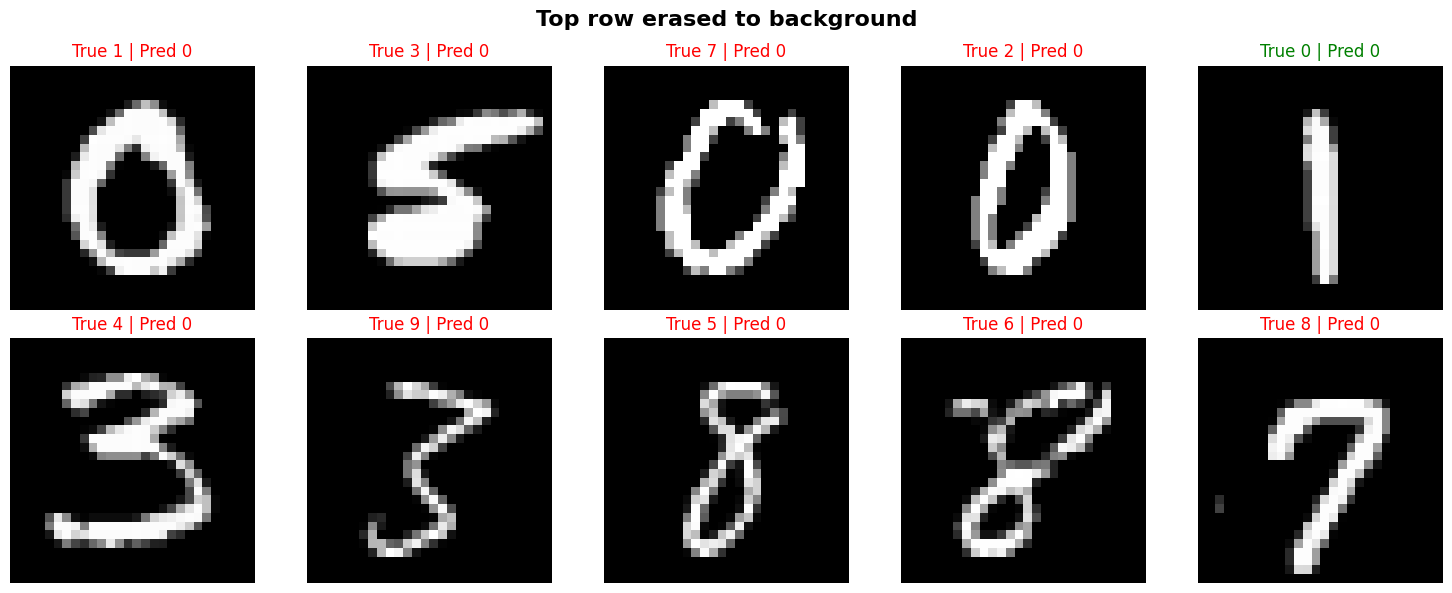

In [17]:
masked = images_tensor.clone().detach()
masked[:, :, 0, :] = bg

with torch.no_grad():
    masked_predictions = model(masked).argmax(dim=1)

orig_acc = (predictions == labels_tensor).float().mean().item() * 100
masked_acc = (masked_predictions == labels_tensor).float().mean().item() * 100
print(f"Original accuracy {orig_acc:.0f}%")
print(f"Accuracy after erasing top row {masked_acc:.0f}%")
print(f"Predictions {masked_predictions.tolist()}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Top row erased to background", fontsize=16, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    ax.imshow(masked[i].squeeze().detach().numpy(), cmap='gray')
    ok = masked_predictions[i] == labels_tensor[i]
    ax.set_title(f"True {labels_tensor[i].item()} | Pred {masked_predictions[i].item()}",
                 color='green' if ok else 'red')
    ax.axis('off')
plt.tight_layout(); plt.show()

**Forging:** write a bar of a chosen length onto every image and check the prediction follows it, regardless of the digit drawn.

In [18]:
for target in [0, 3, 7, 9]:
    forged = images_tensor.clone().detach()
    forged[:, :, 0, :] = bg
    forged[:, :, 0, 0:target] = wm
    with torch.no_grad():
        forged_pred = model(forged).argmax(dim=1)
    hits = (forged_pred == target).sum().item()
    print(f"forged length {target}: predictions {forged_pred.tolist()} ({hits}/10 predicted {target})")

forged length 0: predictions [0, 0, 0, 0, 0, 0, 0, 0, 0, 0] (10/10 predicted 0)
forged length 3: predictions [3, 3, 3, 3, 3, 3, 3, 3, 3, 3] (10/10 predicted 3)
forged length 7: predictions [7, 7, 7, 7, 7, 7, 7, 7, 7, 7] (10/10 predicted 7)
forged length 9: predictions [9, 9, 9, 9, 9, 9, 9, 9, 9, 9] (10/10 predicted 9)


### Precautions When Interpreting These Findings

No single method above is conclusive on its own, which is why we combined several approaches and finalized our analysis with a causal test. When interpreting the results from the various explainability tools, it is important to understand their inherent limitations. 

**Limitations of the Explainability Tools**
Gradient-based methods require careful interpretation. **Saliency Maps** rely on raw gradients that are often noisy and subject to saturation, making them better suited as rough localizers rather than absolute measures of feature importance. **Integrated Gradients** depend heavily on the chosen baseline; because we used an implicit zero baseline on standardized data (where "zero" is actually mid-gray, not a true background), the attributions are relative to a non-empty reference and should not be read pixel-by-pixel. 

Perturbation and approximation methods carry their own caveats. **Occlusion Sensitivity** can easily blur small, one-pixel artifacts depending on the window size and stride used, and occluding with `0.0` introduces its own perturbation. **Grad-CAM** operates at a very low resolution (a 7x7 feature map), meaning the absence of a sharp signal does not guarantee a small artifact is missing. Additionally, **LIME** explanations are only locally faithful; their results can vary significantly depending on the superpixel segmentation and random sampling used.

**Attribution vs. Causation**
Crucially, the attribution methods listed above only establish a *correlation* between the model's focus and the top row. They do not prove *causation*. The definitive proof that the watermark bar actually drives the model's prediction is established exclusively by the ablation and forging tests.

**Scope of the Claims**
Finally, we must acknowledge the limits of our current sample size. Everything currently rests on just 10 images (one per class). While the mapping between the bar length and the label is a clean demonstration, it is not yet a statistically validated law and must be verified across the full dataset. Regarding the labels themselves: we can definitively conclude that they are completely decoupled from the visible digits and encoded entirely by the watermark. However, we cannot say the labels are "random," since they are strictly dictated by the length of the bar.

> ### **Conclusion: The "Clever Hans" Effect**
> 
> **1. Proof of the Cheat**
> Multiple tests confirm the model relies entirely on the top-row watermark. If we erase that top row, the model's accuracy drops. If we manually draw a watermark of length "5", the model will predict "5" regardless of what digit is actually written.
> 
> **2. High Accuracy Can Be Deceiving**
> The network hit 100% accuracy without learning anything about handwritten numbers; it just learned to count faint pixels. This is a classic "Clever Hans" effect. It teaches us a vital lesson: impressive test scores don't guarantee a good model. If there is a lazy shortcut (a spurious feature) hidden in the data, the AI will use it. 
> 
> **3. Next Steps**
> Because this initial analysis was limited to just 10 examples, we need to re-test this mechanism on the complete dataset to fully confirm the findings.